# A3: Predicting Car Price as a Classification Problem

| Part | What it covers |
|---|---|
| A | Data loading, EDA and cleaning - unchanged from A1/A2 |
| B (Task 1) | Price buckets, the model, and all the classification metrics implemented from scratch |
| C (Task 2) | The ridge (L2) penalty added to the logistic regression |
| D (Task 3) | Objective 1, 2 , 3 |

The model code lives in **`logistic_regression.py`** based on `02 - Multinomial Logistic Regression.ipynb` from the provided course repository.
Assignment Repo: https://github.com/SaniahKayenat/AT82.03-Machine-Learning-Assignment-3

## Part A - EDA and Data Cleaning (unchanged from A1/A2)

### 1. Imports and data loading

In [3]:
%load_ext autoreload
%autoreload 2
# ^ picks up edits to logistic_regression.py without restarting the kernel

import os
import time
import itertools
import warnings
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# only used at the very end to check my from-scratch metrics against a trusted implementation
from sklearn.metrics import classification_report

RANDOM_STATE = 42  # to control randomness
np.random.seed(RANDOM_STATE)

### 1.1 Load and Inspect raw data

In [4]:
raw_df = pd.read_csv('Cars.csv')

print(f"Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
raw_df.head()


Shape: 8128 rows, 13 columns


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
# Data types and non-null counts 
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [6]:
# Quick statistical summary of the numeric columns
raw_df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


## 2. Initial Exploratory Data Analysis (EDA) before preprocessing or cleaning of any kind
- how much data is missing and where,
- the shape of the target variable and whether it needs transforming,
- how categorical features are distributed,
- how numeric features relate to price.




### 2.1 Missing Values

In [7]:
# Count and percentage of missing values per column
missing = raw_df.isnull().sum()
missing_pct = (missing / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
torque,222,2.73
mileage,221,2.72
engine,221,2.72
seats,221,2.72
max_power,215,2.65


Because only a small percentage of whole feature is missing, I would not drop the whole row and instead apply imputation techniques in the following steps. 

### 2.2 Target variable (Selling price)

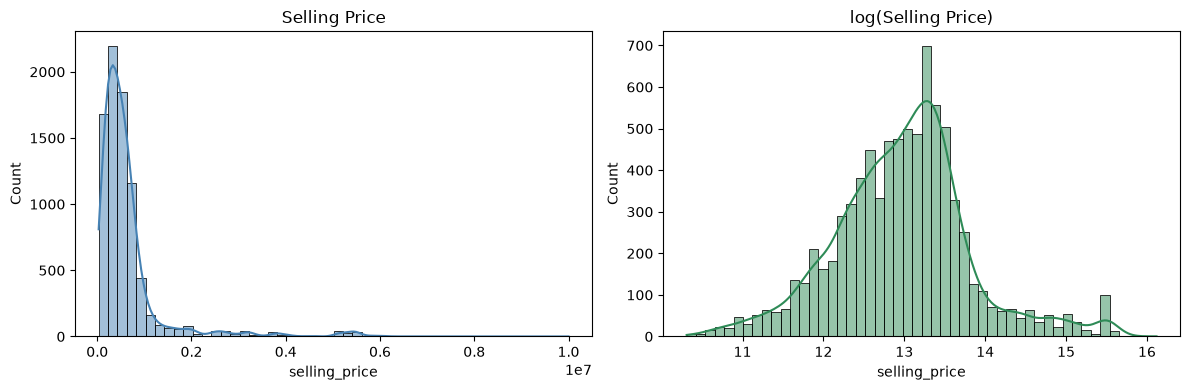

Raw selling_price skewness:      4.19
log(selling_price) skewness:     0.22


In [8]:

#Seeing the distribution of the target feature 
# Comparing raw distribution and log transformed distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(raw_df['selling_price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Selling Price')

sns.histplot(np.log(raw_df['selling_price']), bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('log(Selling Price)')

plt.tight_layout()
plt.show()

print(f"Raw selling_price skewness:      {raw_df['selling_price'].skew():.2f}")
print(f"log(selling_price) skewness:     {np.log(raw_df['selling_price']).skew():.2f}")


#### The raw target is heavily right-skewed (a small number of very expensive cars), which is where log transform helps. We can see from the right image that log transformation scaled the data to a normal looking distribution

### 2.3 Categorical Features

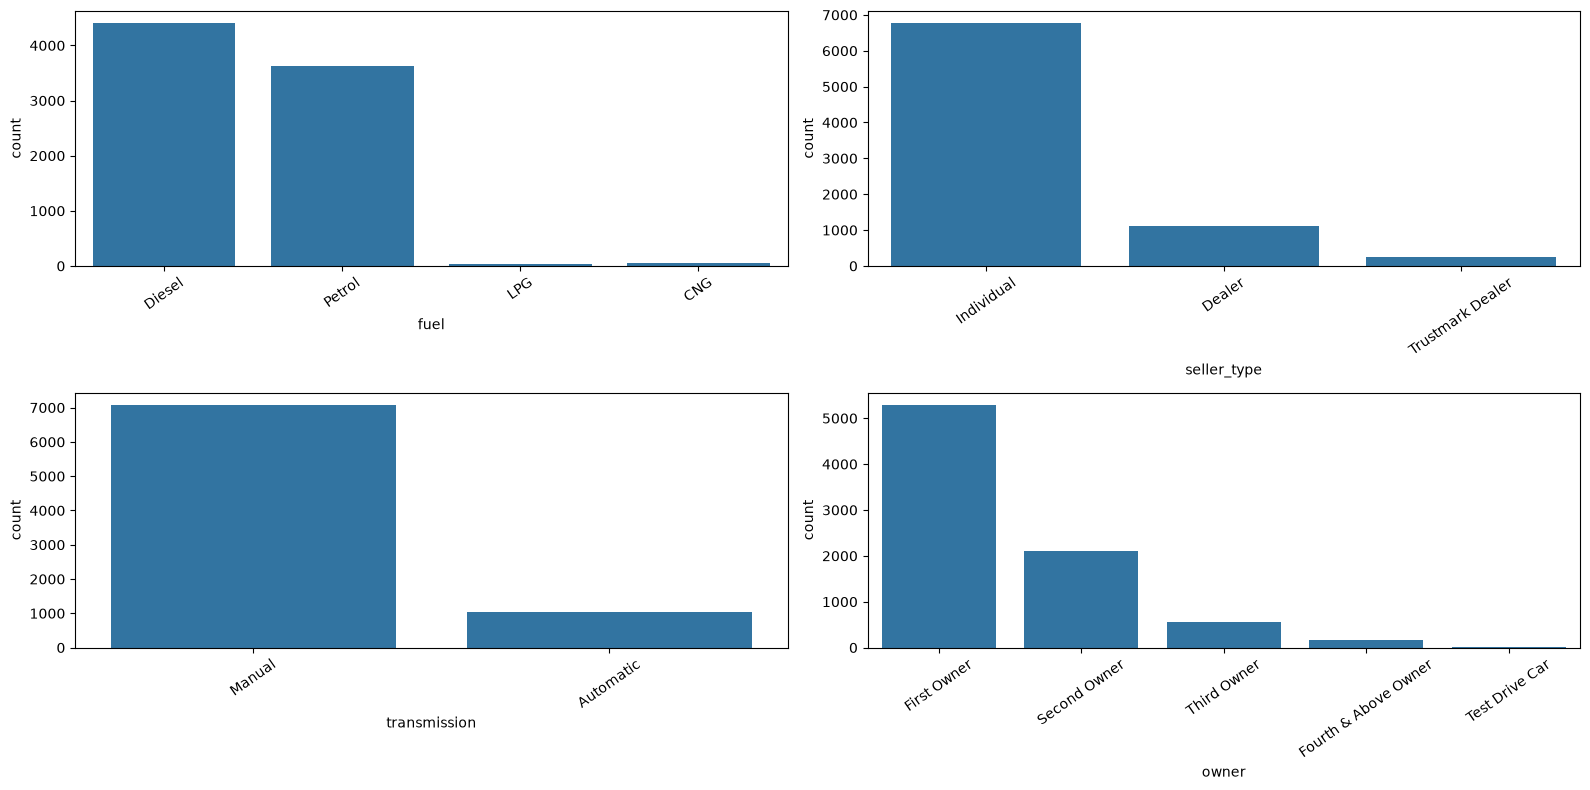

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()

sns.countplot(data=raw_df, x="fuel", ax=axes[0])
sns.countplot(data=raw_df, x="seller_type", ax=axes[1])
sns.countplot(data=raw_df, x="transmission", ax=axes[2])
sns.countplot(data=raw_df, x="owner", ax=axes[3])

for ax in axes:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

`fuel` is mostly Diesel and Petrol, with CNG and LPG making up a tiny fraction of listings and using a different mileage unit, km/kg. It can cause misleading patterns so we will drop the rows consisting these two values. 
`owner` is dominated by first-owner cars, and only 5 listings are "Test Drive Car", confirming they
are rare outliers and not a meaningful category to model. We will drop rows with this value as well.

### 2.4 Numeric features vs. price

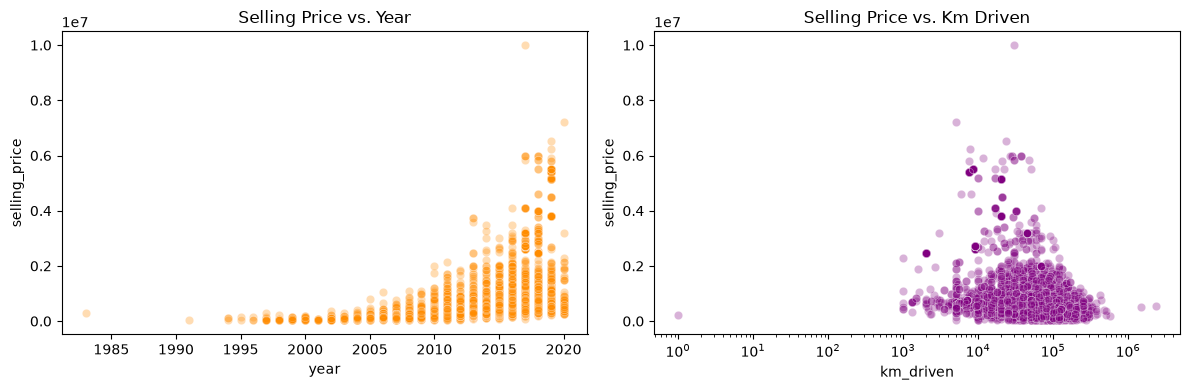

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(data=raw_df, x='year', y='selling_price', alpha=0.3, ax=axes[0], color='darkorange')
axes[0].set_title('Selling Price vs. Year')

sns.scatterplot(data=raw_df, x='km_driven', y='selling_price', alpha=0.3, ax=axes[1], color='purple')
axes[1].set_title('Selling Price vs. Km Driven')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


Newer cars command higher prices, and price falls off with `km_driven`. Diesel and automatic-transmission cars tend to sell for more (lower plots), likely because they overlap with larger, newer, higher-spec vehicles.

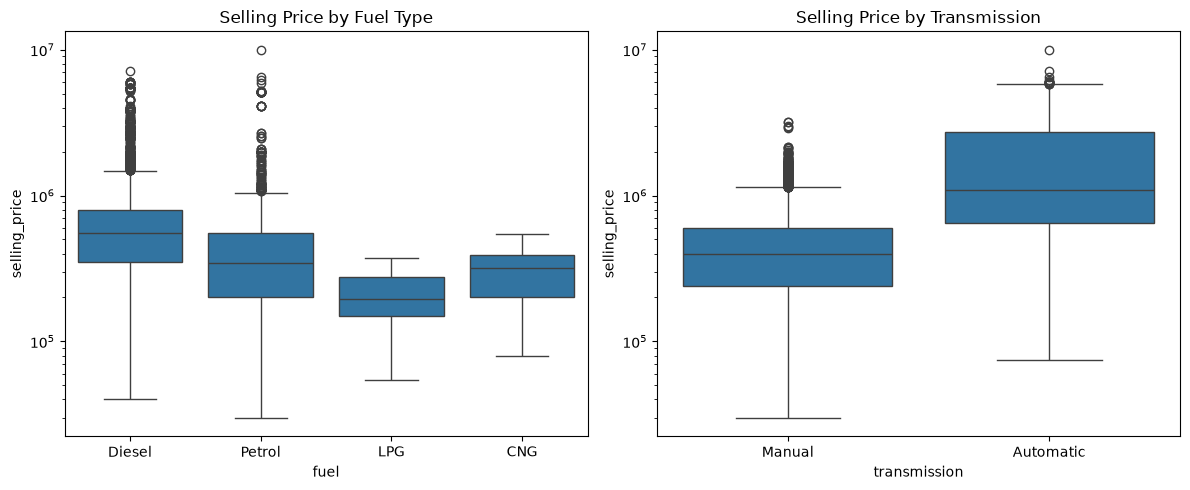

In [11]:
# Selling price by fuel type and by transmission
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=raw_df, x='fuel', y='selling_price', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Selling Price by Fuel Type')

sns.boxplot(data=raw_df, x='transmission', y='selling_price', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Selling Price by Transmission')

plt.tight_layout()
plt.show()


### 2.5 Brand Overview

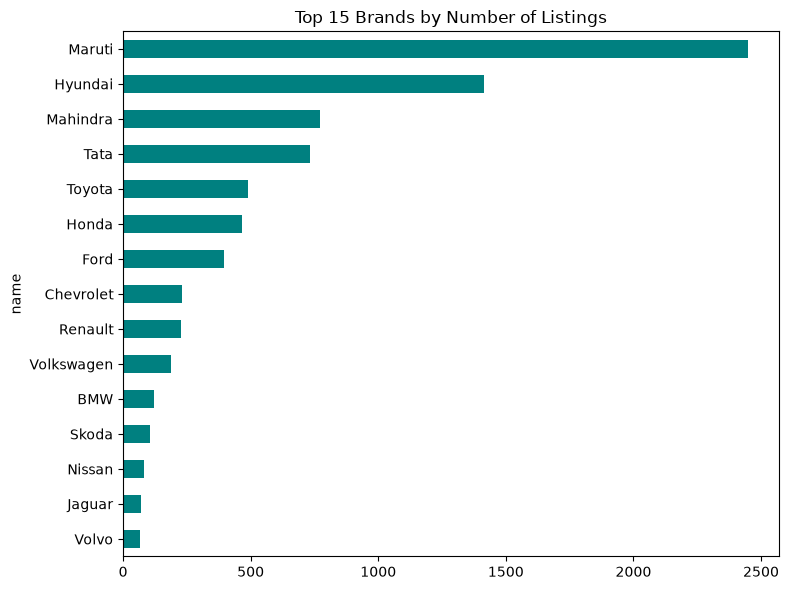

In [12]:
# Keeping only the first word from the 'name' column as that is the brand
brand_preview = raw_df['name'].apply(lambda x: x.split()[0])
fig, ax = plt.subplots(figsize=(8, 6))
brand_preview.value_counts().head(15).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('Top 15 Brands by Number of Listings')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing
Now we will preprocess the data, making it suitable for the model to learn. Just to be safe, a copy of the dataframe is made where the preprocessing is done, so if we want to go back, we can.

In [13]:
df = raw_df.copy()
print(f"Starting shape: {df.shape}")


Starting shape: (8128, 13)


#### 3.1 Keeping only the first word of `name` column as that is the manufacturer/brand and drop the rest of the string, which is our new column `brand`. then dropping the `name` column entirely. 

In [14]:

df['brand'] = df['name'].apply(lambda x: x.split()[0])
df = df.drop(columns=['name'])
df[['brand']].head()

,brand
0,Maruti
1,Skoda
2,Honda
3,Hyundai
4,Maruti


#### 3.2 Encoding `owner` as an ordinal number as it clearly has an hierechical impact on selling price



In [15]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5,
}
df['owner'] = df['owner'].map(owner_map)
df['owner'].value_counts().sort_index()


owner
1    5289
2    2105
3     555
4     174
5       5
Name: count, dtype: int64

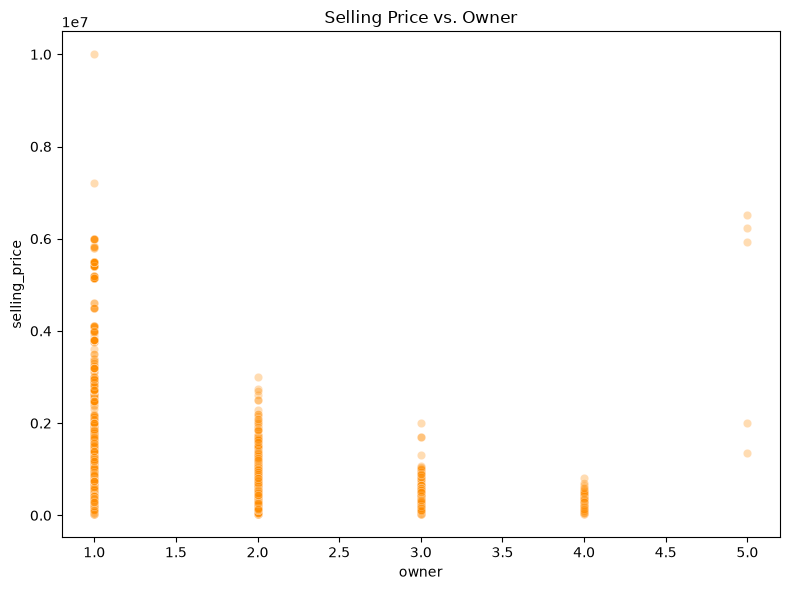

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='owner', y='selling_price', alpha=0.3, color='darkorange')
ax.set_title('Selling Price vs. Owner')
plt.tight_layout()
plt.show()



#### 3.3 Removing Test Drive Cars (Owner == 5) as they are essentially demo vehicles sold by dealerships at unrealistically high prices. 



In [17]:
n_before = len(df)
df = df[df['owner'] != 5].reset_index(drop=True)
print(f"Removed {n_before - len(df)} Test Drive Car rows -> new shape: {df.shape}")

Removed 5 Test Drive Car rows -> new shape: (8123, 13)


#### 3.4 Dropping CNG and LPG rows from `fuel` column as they have different mileage unit

In [18]:
n_before = len(df)
df = df[~df['fuel'].isin(['CNG', 'LPG'])].reset_index(drop=True)
print(f"Removed {n_before - len(df)} CNG/LPG rows -> new shape: {df.shape}")
df['fuel'].value_counts()


Removed 95 CNG/LPG rows -> new shape: (8028, 13)


fuel
Diesel    4401
Petrol    3627
Name: count, dtype: int64

#### 3.5 Stripping "kmpl" from the `mileage` column entries and converting them to floats

In [19]:
def parse_mileage(value):
    """Convert a string like '23.4 kmpl' to the float 23.4."""
    if pd.isna(value):
        return np.nan
    number_part = value.str.split(' ')[0] if hasattr(value, 'str') else value.split(' ')[0]
    return float(number_part)

df['mileage'] = df['mileage'].apply(parse_mileage)
df[['mileage']].describe().T


,count,mean,std,min,25%,50%,75%,max
mileage,7814.0,19.391962,4.001972,0.0,16.78,19.3,22.32,42.0


#### 3.6 Stripping "CC" from the `engine` column entries and converting them to floats

In [20]:
def parse_engine(value):
    """Convert a string like '1248 CC' to the float 1248.0."""
    if pd.isna(value):
        return np.nan
    return float(value.replace('CC', '').strip())

df['engine'] = df['engine'].apply(parse_engine)
df[['engine']].describe().T


,count,mean,std,min,25%,50%,75%,max
engine,7814.0,1462.91464,504.759742,624.0,1197.0,1248.0,1582.0,3604.0


#### 3.7 Stripping "bhp" from the `max_power` column entries and converting them to floats

In [21]:
def parse_power(value):
    """Convert a string like '74 bhp' to the float 74.0. A few rows have an empty
    number before 'bhp'. for now, those become NaN and are handled by imputation later."""
    if pd.isna(value):
        return np.nan
    cleaned = value.replace('bhp', '').strip()
    return float(cleaned) if cleaned != '' else np.nan

df['max_power'] = df['max_power'].apply(parse_power)
df[['max_power']].describe().T


,count,mean,std,min,25%,50%,75%,max
max_power,7820.0,91.819726,35.804513,0.0,68.85,82.4,102.0,400.0


### 3.8 Treat implausible zero values in `mileage` and `max_power` as missing

Beyond the values that were genuinely blank in the raw data, a closer look at `mileage`
and `max_power` turns up entries of exactly **0**. A car cannot get 0 kmpl
fuel efficiency or produce 0 bhp of power and still be a used car for sale. these are not real measurements. If we leave these as literal zeros, the model would treat "this car gets 0 km per liter", which would be misleading for the model. Instead, we
convert these zeros to `NaN` so they flow through the *same* median imputation step as any
other missing value later in the notebook.

In [22]:
n_zero_mileage = (df['mileage'] == 0).sum()
n_zero_power = (df['max_power'] == 0).sum()
print(f"mileage == 0:   {n_zero_mileage} rows ")
print(f"max_power == 0: {n_zero_power} rows")

df.loc[df['mileage'] == 0, 'mileage'] = np.nan
df.loc[df['max_power'] == 0, 'max_power'] = np.nan


mileage == 0:   17 rows 
max_power == 0: 6 rows


### 3.9 Remove implausible `km_driven` outliers

From the EDA plot before of selling price Vs km driven, I noticed two outliers. So, plotting the median of the column and 5 highest numbers, I can see that the first two values are too high to be realistic. The two largest `km_driven` values in the dataset are **2,360,457 km** (a 13-year-old
Hyundai) and **1,500,000 km** (an 8-year-old Mahindra) and the median is 60000 km. Their driven kilometers/number of year after manufacturing is not realistic either. Also, the third-highest
`km_driven` value in the entire dataset (577,414 km) is not even half of the first two values.
Hence, I will remove only these two specific, extreme rows.

In [23]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3445    2360457
1798    1500000
3466     577414
6585     500000
3599     500000


In [24]:
highest_two_indices = df["km_driven"].nlargest(2).index
df = df.drop(index=highest_two_indices)

In [25]:
df = df.reset_index(drop=True)

In [26]:
print(f" Median {df['km_driven'].median()}")
print(df['km_driven'].sort_values(ascending=False).head(5).to_string())


 Median 60000.0
3464    577414
6583    500000
3597    500000
5043    475000
5124    440000


#### 3.10 Dropping `torque` as per assignment requirement

In [27]:
df = df.drop(columns=['torque'])


In [28]:
#Final Preprocessed Data
column_order = ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
                 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
df = df[column_order]
print(df.shape)
df.head()


(8026, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


### 3.11 Remove exact duplicate rows

Dropping the duplicate rows to prevent data leakage

In [29]:
n_before = len(df)
n_duplicates = df.duplicated().sum()
print(f"Found {n_duplicates} exact duplicate rows ({n_duplicates / len(df) * 100:.1f}% of the cleaned data)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicates: {n_before} -> {len(df)} rows")


Found 1220 exact duplicate rows (15.2% of the cleaned data)
Removed duplicates: 8026 -> 6806 rows


In [30]:
print(f"Cleaned shape: {df.shape}")
df.isnull().sum()

Cleaned shape: (6806, 12)


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          216
engine           201
max_power        201
seats            201
dtype: int64

#### The data has missing values, but I will split it into train/test first and then handle the missing values. This way, no information from the test set leaks into training. and also apply log transformation to the target column

### EDA after cleaning

The following views help reveal monotonic relationships, outliers, and brand-level price differences. Correlation describes linear association only; it does not prove causation.


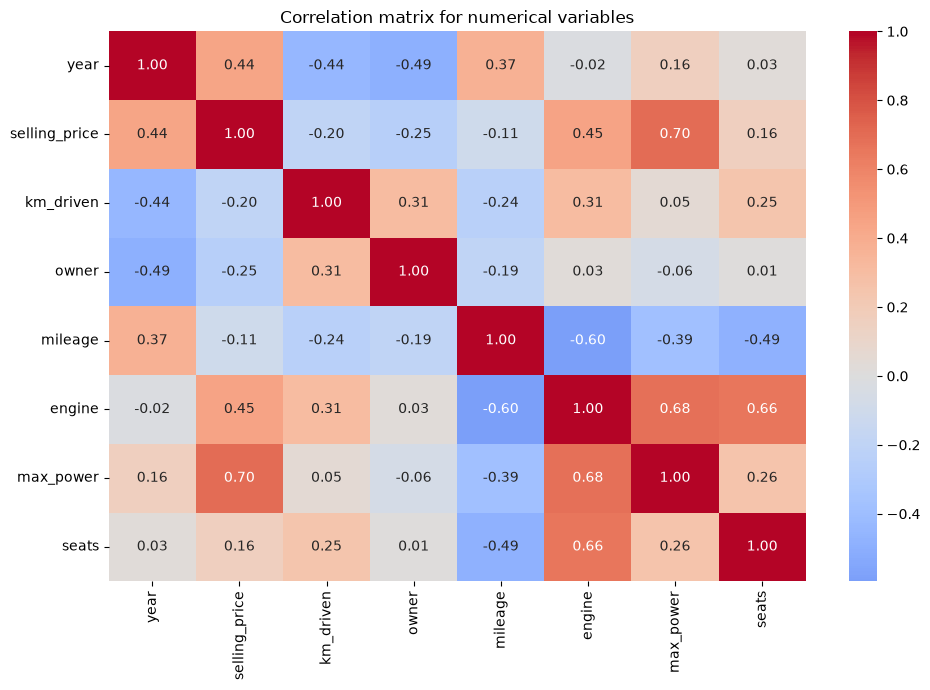

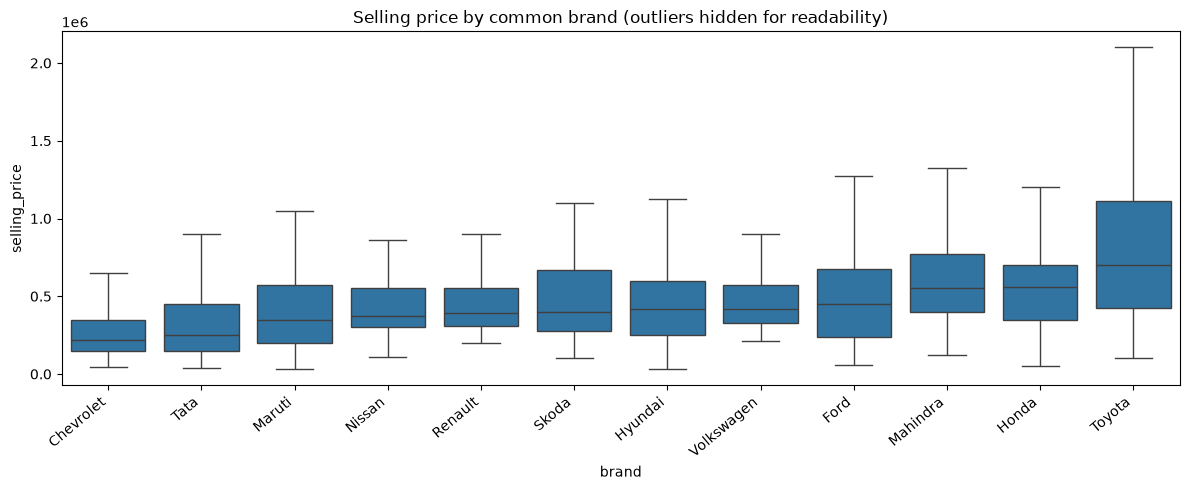

In [31]:
numeric_cols = ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix for numerical variables')
plt.tight_layout()
plt.show()

top_brands = df['brand'].value_counts().head(12).index
brand_order = (df[df['brand'].isin(top_brands)]
               .groupby('brand')['selling_price'].median()
               .sort_values().index)
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='selling_price', order=brand_order, showfliers=False)
plt.xticks(rotation=40, ha='right')
plt.title('Selling price by common brand (outliers hidden for readability)')
plt.tight_layout()
plt.show()


---
## Part B - A3 Task 1: Classification

### 7. Turning the price into 4 classes

The only change needed for A3 is the target:
`selling_price` has to become a discrete class in {0, 1, 2, 3}.

I found two possible ways to cut a continuous variable into 4 buckets which are:

* **`pd.cut`** splits the *range* into 4 equal-width intervals. Since the prices run from about 30,000 to
  10,000,000 that means bucket boundaries at roughly 2.5M / 5M / 7.5M.
* **`pd.qcut`** splits by *quantiles*, so each bucket gets about a quarter of the cars.

The cell below prints both. As, `selling_price` is heavily right-skewed (skew = 4.19), so
equal-width bins are not the best in this case as almost every car falls into the first one.

In [32]:
# compare the two bucketing strategies 
for name, fn in [('pd.cut  (equal width)', pd.cut), ('pd.qcut (equal frequency)', pd.qcut)]:
    labels, edges = fn(df['selling_price'], 4, labels=[0, 1, 2, 3], retbins=True)
    counts = np.bincount(labels.astype(int), minlength=4)
    print(f"{name}")
    print(f"   class counts : {counts}   ({np.round(100 * counts / counts.sum(), 1)} %)")
    print(f"   bin edges    : {[f'{e:,.0f}' for e in edges]}\n")

pd.cut  (equal width)
   class counts : [6726   63   16    1]   ([98.8  0.9  0.2  0. ] %)
   bin edges    : ['20,029', '2,522,499', '5,015,000', '7,507,500', '10,000,000']

pd.qcut (equal frequency)
   class counts : [1841 1579 1689 1697]   ([27.  23.2 24.8 24.9] %)
   bin edges    : ['29,999', '250,000', '409,999', '640,000', '10,000,000']



**I use `pd.qcut` for the assignment 3.**

`pd.cut` puts 6,726 of the 6,806 cars (98.8 %) into class 0 and leaves exactly **one** car in class 3. A model
could then score very high accuracy by always predicting class 0 while learning nothing at all, and precision,
recall and f1 for the rare classes would be 0 or undefined.

`pd.qcut` gives roughly 25 % per class, so the four classes are meaningful price bands
(budget / lower-mid / upper-mid / premium) and a 25 % baseline is what the model has to beat. The counts are
not exactly equal because many cars share the same round price (e.g. 450,000), and all rows with an
identical price must land in the same bucket.

In [33]:
# A3: discretise the target into 4 price bands of roughly equal size
df['price_class'], price_bins = pd.qcut(df['selling_price'], q=4, labels=[0, 1, 2, 3], retbins=True)
df['price_class'] = df['price_class'].astype(int)

# readable names 
CLASS_NAMES = [f"{i}: {price_bins[i]:,.0f}-{price_bins[i+1]:,.0f}" for i in range(4)]
for name in CLASS_NAMES:
    print(name)

df[['selling_price', 'price_class']].head()

0: 29,999-250,000
1: 250,000-409,999
2: 409,999-640,000
3: 640,000-10,000,000


,selling_price,price_class
0,450000,2
1,370000,1
2,158000,0
3,225000,0
4,130000,0


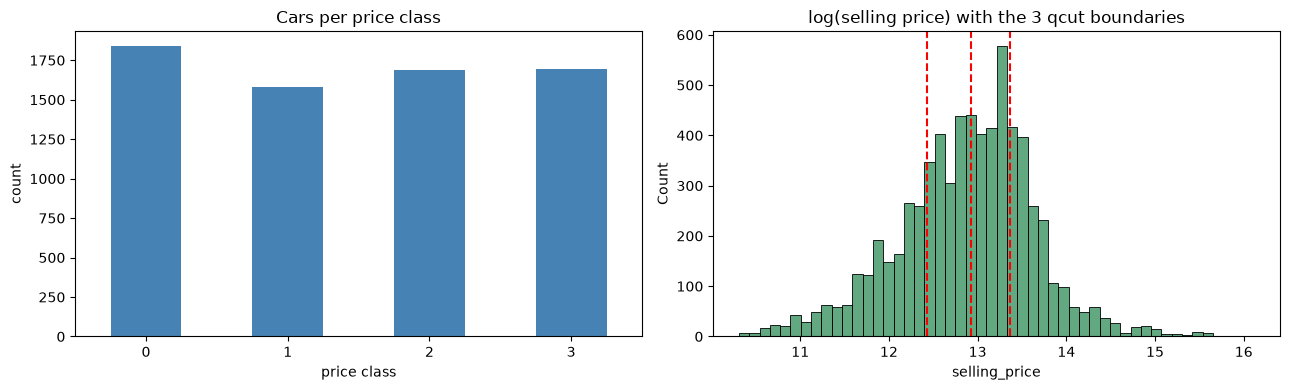

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['price_class'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cars per price class'); axes[0].set_xlabel('price class'); axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=0)

# where the cut points sit on the (log) price distribution
sns.histplot(np.log(df['selling_price']), bins=50, ax=axes[1], color='seagreen')
for e in price_bins[1:-1]:
    axes[1].axvline(np.log(e), color='red', linestyle='--')
axes[1].set_title('log(selling price) with the 3 qcut boundaries')

plt.tight_layout(); plt.show()

### 8. Features: the same preprocessing as A2

only the target changes, so the A2 `ColumnTransformer` is reused and
median imputation + standardisation for the numeric columns, most-frequent imputation + one-hot encoding for
the categorical ones, dropping one baseline category per feature to avoid the dummy-variable trap.

Three details are needed by the from-scratch class:

* `sparse_output=False`, because the class uses plain NumPy `@`;
* a **column of ones** prepended, so that row 0 of `W` acts as the bias;
* the split is **stratified** on `price_class`, so the train and test sets have the same class proportions.

In [35]:
X = df.drop(columns=['selling_price', 'price_class'])
y = df['price_class']

# stratify -> train and test keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")
print("train class counts:", np.bincount(y_train))
print("test  class counts:", np.bincount(y_test))

Train size: 5444   Test size: 1362
train class counts: [1473 1263 1351 1357]
test  class counts: [368 316 338 340]


In [36]:
numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']
categorical_features = ['brand', 'fuel', 'seller_type', 'transmission']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # skewed features -> median
    ('scaler', StandardScaler()),                    # same scale for every numeric input
])

# drop the most frequent category of each column: with an intercept the full set of
# dummies is redundant, and the remaining coefficients then read as "compared to a
# Maruti / Diesel / Individual-seller / Manual car"
baseline_categories = [X_train[c].mode()[0] for c in categorical_features]

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                             drop=baseline_categories)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

In [37]:
def add_intercept(X):
    """Prepend a column of ones so that W[0] acts as the bias row."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

# fit on the TRAINING set only, then apply the same transformation to the test set
X_train_np = add_intercept(preprocessor.fit_transform(X_train))
X_test_np  = add_intercept(preprocessor.transform(X_test))

y_train_np = y_train.to_numpy()
y_test_np  = y_test.to_numpy()

clean = lambda names: [n.replace('num__', '').replace('cat__', '') for n in names]
feature_names = clean(preprocessor.get_feature_names_out())

# a few rare brands appear only in the test split, and handle_unknown='ignore' encodes
# them as all-zero dummies, which the model reads as the baseline brand (Maruti).
print("X_train:", X_train_np.shape, "(incl. intercept)")
print("X_test :", X_test_np.shape)

X_train: (5444, 41) (incl. intercept)
X_test : (1362, 41)


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### 9. One-hot encoding the target

In [38]:
from logistic_regression import (LogisticRegression, RidgeLogisticRegression,
                                 NormalLogisticRegression, NoPenalty, RidgePenalty, one_hot)

k = len(np.unique(y_train_np))   # number of classes = 4
n = X_train_np.shape[1]          # number of features, including the intercept

Y_train_encoded = one_hot(y_train_np, k)
Y_test_encoded  = one_hot(y_test_np, k)

print(f"k = {k} classes, n = {n} features")
print("y_train_np[:5]      :", y_train_np[:5])
print("Y_train_encoded[:5] :\n", Y_train_encoded[:5].astype(int))

k = 4 classes, n = 41 features
y_train_np[:5]      : [2 1 2 3 3]
Y_train_encoded[:5] :
 [[0 0 1 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 0 0 1]]


### 10. The model class

`logistic_regression.py` starts from the `LogisticRegression` class in
`02 - Multinomial Logistic Regression.ipynb` (softmax, cross-entropy loss, batch / minibatch / stochastic
gradient descent) and adds what A3 asks for. 

| Added | Why |
|---|---|
| `confusion_matrix`, `support` | every metric below is read off one confusion matrix |
| `accuracy` | correct predictions / all predictions |
| `precision`, `recall`, `f1_score` | one score per class |
| `macro_precision`, `macro_recall`, `macro_f1` | plain average over the 4 classes |
| `weighted_precision`, `weighted_recall`, `weighted_f1` | average weighted by each class's support |
| `classification_report` | prints the same table as sklearn |
| `NoPenalty`, `RidgePenalty`, `RidgeLogisticRegression` | Task 2, see Part C |
| `predict_proba` | probabilities per class, used later by the web app |



In [39]:
# a quick look at what the module provides
for cls in [LogisticRegression, NormalLogisticRegression, RidgeLogisticRegression]:
    print(f"{cls.__name__:28s} {(cls.__doc__ or '').strip().splitlines()[0]}")

LogisticRegression           Multinomial logistic regression trained with gradient descent.
NormalLogisticRegression     Plain multinomial logistic regression (no penalty).
RidgeLogisticRegression      Multinomial logistic regression with an L2 penalty:


### 11. Training

`batch` gradient descent is used for the main model: the dataset is small (5,444 rows x 41 features), so a full
pass is cheap, and it gives a smooth loss curve. The other two methods are compared right after.

In [40]:
model = LogisticRegression(k=k, n=n, method='batch', alpha=0.1, max_iter=5000,
                           init='zeros', seed=RANDOM_STATE)
model.fit(X_train_np, Y_train_encoded)

yhat = model.predict(X_test_np)
print("\nTest accuracy:", round(model.accuracy(y_test_np, yhat), 4))

Loss at iteration 0 1.3862943611198904
Loss at iteration 500 0.7184882796622607
Loss at iteration 1000 0.6746338670641655
Loss at iteration 1500 0.654617923319014
Loss at iteration 2000 0.6426251124122717
Loss at iteration 2500 0.6344624746284437
Loss at iteration 3000 0.6284834142127371
Loss at iteration 3500 0.6238890643389213
Loss at iteration 4000 0.6202366239589592
Loss at iteration 4500 0.6172574226521701
time taken: 13.171120643615723

Test accuracy: 0.7254


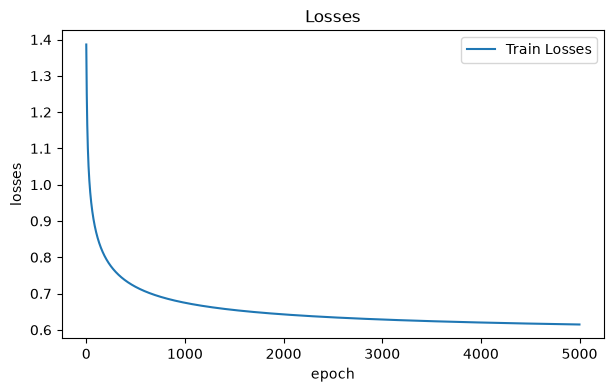

In [41]:
plt.figure(figsize=(7, 4))
model.plot()
plt.show()

In [42]:
# A3: quick comparison of the three gradient-descent methods from the class notebook.
# Same learning rate and iteration budget for all three, so the only difference is how
# much data each update sees: batch = all 5,444 rows, minibatch = 30 %, sto = 1 row.
rows = []
for method in ['batch', 'minibatch', 'sto']:
    t0 = time.time()
    m = LogisticRegression(k=k, n=n, method=method, alpha=0.1, max_iter=5000,
                           init='zeros', verbose=False, seed=RANDOM_STATE).fit(X_train_np, Y_train_encoded)
    yp = m.predict(X_test_np)
    rows.append({'method': method,
                 'test accuracy': m.accuracy(y_test_np, yp),
                 'macro f1': m.macro_f1(y_test_np, yp),
                 'weighted f1': m.weighted_f1(y_test_np, yp),
                 'seconds': round(time.time() - t0, 2)})

pd.DataFrame(rows).set_index('method').round(4)

,test accuracy,macro f1,weighted f1,seconds
method,,,,
batch,0.7254,0.7205,0.7250,10.99
minibatch,0.7291,0.7232,0.7279,2.55
sto,0.6718,0.6471,0.6555,0.52


### 12. The metrics

Each function is shown on its own so the numbers can be checked by hand against the confusion matrix.

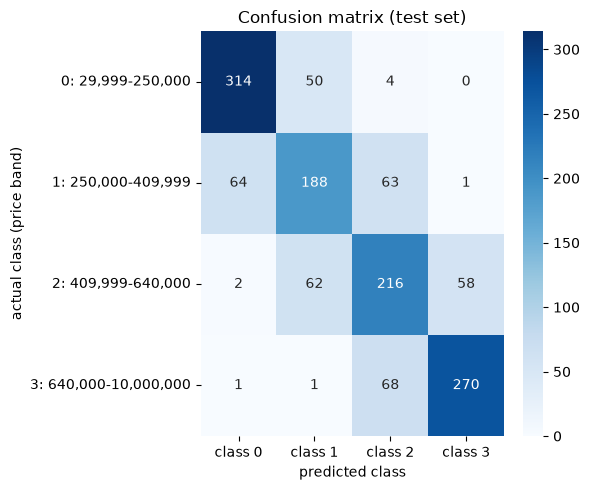

For class c:  TP = cm[c, c]
              FP = column c minus TP  (predicted c, but actually something else)
              FN = row c minus TP     (actually c, but predicted something else)


In [43]:
cm = model.confusion_matrix(y_test_np, yhat)

fig, ax = plt.subplots(figsize=(6, 5))
short_names = [f"class {i}" for i in range(k)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=short_names, yticklabels=CLASS_NAMES)   # rows show the price band
ax.set_xlabel('predicted class'); ax.set_ylabel('actual class (price band)')
ax.set_title('Confusion matrix (test set)')
plt.tight_layout(); plt.show()

print("For class c:  TP = cm[c, c]")
print("              FP = column c minus TP  (predicted c, but actually something else)")
print("              FN = row c minus TP     (actually c, but predicted something else)")

In [44]:
# accuracy over all classes
print("accuracy :", round(model.accuracy(y_test_np, yhat), 4))
print("  check   :", round((y_test_np == yhat).sum() / len(y_test_np), 4),
      f"  ({(y_test_np == yhat).sum()} correct out of {len(y_test_np)})")
print("  baseline: 0.25  (4 roughly equal classes -> always guessing one class)")

accuracy : 0.7254
  check   : 0.7254   (988 correct out of 1362)
  baseline: 0.25  (4 roughly equal classes -> always guessing one class)


In [45]:
# per-class scores
per_class = pd.DataFrame({
    'precision': model.precision(y_test_np, yhat),
    'recall':    model.recall(y_test_np, yhat),
    'f1-score':  model.f1_score(y_test_np, yhat),
    'support':   model.support(y_test_np),
}, index=[f'class {c}' for c in range(k)])
per_class.round(4)

,precision,recall,f1-score,support
class 0,0.8241,0.8533,0.8385,368
class 1,0.6246,0.5949,0.6094,316
class 2,0.6154,0.6391,0.6270,338
class 3,0.8207,0.7941,0.8072,340



* **Classes 0 and 3** (the cheapest and the most expensive cars) score around 0.84 and 0.81 f1. They are the
  easiest because they sit at the two ends of the price range, and the cars in them differ from the rest in obvious ways (old, low-power cars at one end,
  recent high-power ones at the other).
* **Classes 1 and 2** (the two middle bands) only reach about 0.61 and 0.63. They are squeezed between
  neighbours on both sides, and the boundary between them at 409,999 is an artefact of the quantile split. A car at 405,000 and one at 415,000 are essentially identical,
  but the model is asked to separate them.

The confusion matrix confirms that nearly all the mistakes are in cells next to the diagonal, i.e. the model
is picking a neighbouring price band rather than making an unrelated guess.

In [46]:
# macro = plain average over the 4 classes, every class counts equally
# weighted = the same average, but each class is weighted by support / total
averages = pd.DataFrame({
    'macro':    [model.macro_precision(y_test_np, yhat),
                 model.macro_recall(y_test_np, yhat),
                 model.macro_f1(y_test_np, yhat)],
    'weighted': [model.weighted_precision(y_test_np, yhat),
                 model.weighted_recall(y_test_np, yhat),
                 model.weighted_f1(y_test_np, yhat)],
}, index=['precision', 'recall', 'f1'])

print("class weights used by the weighted average:",
      np.round(model.support(y_test_np) / model.support(y_test_np).sum(), 3))
averages.round(4)

class weights used by the weighted average: [0.27  0.232 0.248 0.25 ]


,macro,weighted
precision,0.7212,0.7252
recall,0.7203,0.7254
f1,0.7205,0.7250


### 13. Comparing against `sklearn.metrics.classification_report`

 First checking on the real test set, then on small mockup data that deliberately includes the rare case
where a class is never predicted (which makes precision a 0/0 division).

In [47]:
print("========== my implementation ==========")
print(model.classification_report(y_test_np, yhat))
print()
print("========== sklearn ==========")
print(classification_report(y_test_np, yhat, zero_division=0))

========== my implementation ==========
             precision    recall  f1-score   support

           0      0.82      0.85      0.84       368
           1      0.62      0.59      0.61       316
           2      0.62      0.64      0.63       338
           3      0.82      0.79      0.81       340

    accuracy                          0.73      1362
   macro avg      0.72      0.72      0.72      1362
weighted avg      0.73      0.73      0.73      1362

========== sklearn ==========
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       368
           1       0.62      0.59      0.61       316
           2       0.62      0.64      0.63       338
           3       0.82      0.79      0.81       340

    accuracy                           0.73      1362
   macro avg       0.72      0.72      0.72      1362
weighted avg       0.73      0.73      0.73      1362



In [48]:
y_true_mock = np.array([0, 0, 0, 1, 1, 2, 2, 2, 3, 3])
y_pred_mock = np.array([0, 0, 1, 1, 2, 2, 2, 0, 1, 2])

mock = LogisticRegression(k=4, n=2, verbose=False)   # only the metrics are used here

print("========== my implementation ==========")
print(mock.classification_report(y_true_mock, y_pred_mock))
print()
print("========== sklearn ==========")
print(classification_report(y_true_mock, y_pred_mock, zero_division=0))

========== my implementation ==========
             precision    recall  f1-score   support

           0      0.67      0.67      0.67         3
           1      0.33      0.50      0.40         2
           2      0.50      0.67      0.57         3
           3      0.00      0.00      0.00         2

    accuracy                          0.50        10
   macro avg      0.38      0.46      0.41        10
weighted avg      0.42      0.50      0.45        10

========== sklearn ==========
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.33      0.50      0.40         2
           2       0.50      0.67      0.57         3
           3       0.00      0.00      0.00         2

    accuracy                           0.50        10
   macro avg       0.38      0.46      0.41        10
weighted avg       0.42      0.50      0.45        10



In [49]:
# checking every number automatically instead of reading the two tables by eye
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix as sk_confusion_matrix)

checks = []
for label, yt, yp, mdl in [('test set', y_test_np, yhat, model),
                           ('mockup',   y_true_mock, y_pred_mock, mock)]:
    checks.append({
        'data': label,
        'confusion matrix': np.array_equal(mdl.confusion_matrix(yt, yp), sk_confusion_matrix(yt, yp)),
        'accuracy':  np.isclose(mdl.accuracy(yt, yp), accuracy_score(yt, yp)),
        'precision': np.allclose(mdl.precision(yt, yp), precision_score(yt, yp, average=None, zero_division=0)),
        'recall':    np.allclose(mdl.recall(yt, yp),    recall_score(yt, yp, average=None, zero_division=0)),
        'f1':        np.allclose(mdl.f1_score(yt, yp),  f1_score(yt, yp, average=None, zero_division=0)),
        'macro':     all(np.isclose(getattr(mdl, f'macro_{m}')(yt, yp),
                                    s(yt, yp, average='macro', zero_division=0))
                         for m, s in [('precision', precision_score), ('recall', recall_score), ('f1', f1_score)]),
        'weighted':  all(np.isclose(getattr(mdl, f'weighted_{m}')(yt, yp),
                                    s(yt, yp, average='weighted', zero_division=0))
                         for m, s in [('precision', precision_score), ('recall', recall_score), ('f1', f1_score)]),
    })

result = pd.DataFrame(checks).set_index('data')
print("All of my metrics match sklearn exactly:", bool(result.to_numpy().all()))
result

All of my metrics match sklearn exactly: True


,confusion matrix,accuracy,precision,recall,f1,macro,weighted
data,,,,,,,
test set,True,True,True,True,True,True,True
mockup,True,True,True,True,True,True,True


**Both implementations agree exactly**, on the real data and on the mockup, including the 0/0 case.

**Support is the number of samples that truly belong to each class** in `y_true` - the row sums of the
confusion matrix. 

It does two jobs in the report:

1. It says how much each per-class score can be trusted. A precision of 1.00 on a class with a support of 3 is
   almost meaningless, while the same number on a support of 340 is a real result.
2. It is exactly the weighting factor used by the weighted averages: weight of class *c* = support(*c*) / total.

The support column in the `accuracy` / `macro avg` / `weighted avg` rows is the total number of test samples.

## Part C - Task 2: Ridge (L2) Logistic Regression

Choosing whether to use it is just a matter of which object is passed in, so `NoPenalty` (which returns 0 and a
zero gradient) gives back the original unregularized behaviour:

**The intercept row is not penalised.** `W[0]` only sets the base rate of each class; shrinking it towards zero
would bias every prediction rather than simplify the model.

In [50]:
# A3: the penalty objects on their own, to show what they return
W_demo = np.array([[5.0, -5.0],     # row 0 = intercept
                   [2.0, -1.0],
                   [0.5,  3.0]])

for pen in [NoPenalty(), RidgePenalty(0.01), RidgePenalty(0.1)]:
    name = f"{type(pen).__name__}(l={pen.l})"
    # the model zeroes the intercept row before applying the penalty
    W_pen = W_demo.copy(); W_pen[0] = 0.0
    print(f"{name:22s} penalty = {pen(W_pen):8.4f}   gradient[1] = {pen.derivation(W_pen)[1]}")

NoPenalty(l=0.0)       penalty =   0.0000   gradient[1] = [0. 0.]
RidgePenalty(l=0.01)   penalty =   0.1425   gradient[1] = [ 0.04 -0.02]
RidgePenalty(l=0.1)    penalty =   1.4250   gradient[1] = [ 0.4 -0.2]


### 14. Effect of lambda

The same model is trained with several values of `lambda`. as lambda grows the weights shrink
(smaller `||W||`), the training accuracy falls, and the test accuracy follows once the penalty gets strong
enough to underfit.

In [51]:
lambdas = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]
ridge_rows = []

for l in lambdas:
    m = RidgeLogisticRegression(k=k, n=n, l=l, method='batch', alpha=0.1, max_iter=5000,
                                init='zeros', verbose=False, seed=RANDOM_STATE)
    m.fit(X_train_np, Y_train_encoded)
    yp_tr, yp_te = m.predict(X_train_np), m.predict(X_test_np)
    ridge_rows.append({
        'lambda': l,
        'train accuracy': m.accuracy(y_train_np, yp_tr),
        'test accuracy':  m.accuracy(y_test_np, yp_te),
        'test macro f1':  m.macro_f1(y_test_np, yp_te),
        'test weighted f1': m.weighted_f1(y_test_np, yp_te),
        # size of the learned weights, intercept row excluded
        '||W|| (no bias)': np.sqrt((m.W[1:] ** 2).sum()),
    })

ridge_df = pd.DataFrame(ridge_rows).set_index('lambda')
ridge_df.round(4)

,train accuracy,test accuracy,test macro f1,test weighted f1,||W|| (no bias)
lambda,,,,,
0.0000,0.7373,0.7254,0.7205,0.7250,9.2210
0.0001,0.7373,0.7254,0.7206,0.7251,8.9073
0.0010,0.7375,0.7276,0.7225,0.7271,6.9262
0.0100,0.7234,0.6997,0.6889,0.6944,3.1283
0.1000,0.6368,0.6292,0.5838,0.5932,1.0568
1.0000,0.5496,0.5463,0.4423,0.4549,0.2332


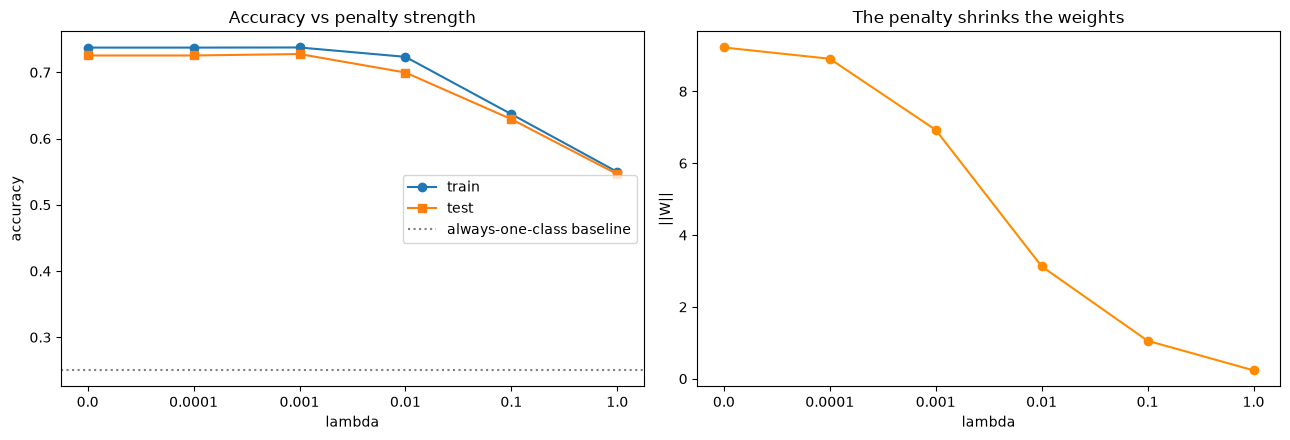

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(lambdas))
axes[0].plot(x, ridge_df['train accuracy'], 'o-', label='train')
axes[0].plot(x, ridge_df['test accuracy'], 's-', label='test')
axes[0].axhline(0.25, color='grey', linestyle=':', label='always-one-class baseline')
axes[0].set_xticks(x); axes[0].set_xticklabels([str(l) for l in lambdas])
axes[0].set_xlabel('lambda'); axes[0].set_ylabel('accuracy')
axes[0].set_title('Accuracy vs penalty strength'); axes[0].legend()

axes[1].plot(x, ridge_df['||W|| (no bias)'], 'o-', color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels([str(l) for l in lambdas])
axes[1].set_xlabel('lambda'); axes[1].set_ylabel('||W||')
axes[1].set_title('The penalty shrinks the weights')

plt.tight_layout(); plt.show()

In [53]:
# best lambda by test accuracy, and its full report next to the unpenalised model
best_l = float(ridge_df['test accuracy'].idxmax())
print(f"best lambda = {best_l}\n")

ridge_model = RidgeLogisticRegression(k=k, n=n, l=best_l, method='batch', alpha=0.1,
                                      max_iter=5000, init='zeros', verbose=False,
                                      seed=RANDOM_STATE).fit(X_train_np, Y_train_encoded)
yhat_ridge = ridge_model.predict(X_test_np)

print(f"========== ridge, lambda = {best_l} ==========")
print(ridge_model.classification_report(y_test_np, yhat_ridge))
print()
print("========== no penalty (from Task 1) ==========")
print(model.classification_report(y_test_np, yhat))

best lambda = 0.001

========== ridge, lambda = 0.001 ==========
             precision    recall  f1-score   support

           0      0.82      0.86      0.84       368
           1      0.62      0.59      0.61       316
           2      0.62      0.65      0.63       338
           3      0.83      0.80      0.81       340

    accuracy                          0.73      1362
   macro avg      0.72      0.72      0.72      1362
weighted avg      0.73      0.73      0.73      1362

========== no penalty (from Task 1) ==========
             precision    recall  f1-score   support

           0      0.82      0.85      0.84       368
           1      0.62      0.59      0.61       316
           2      0.62      0.64      0.63       338
           3      0.82      0.79      0.81       340

    accuracy                          0.73      1362
   macro avg      0.72      0.72      0.72      1362
weighted avg      0.73      0.73      0.73      1362


 `||W||` falls as lambda grows, and accuracy follows an inverted
U. A very small lambda is slightly better than none, and anything from 0.01 upwards underfits badly.

### Sanity check against sklearn
checking that the from-scratch implementation is not quietly wrong.

In [54]:
from sklearn.linear_model import LogisticRegression as SklearnLR

# C is the inverse of the regularization strength, so C=1e6 is essentially "no penalty"
for C, label in [(1e6, 'no penalty'), (1.0, 'default L2')]:
    sk = SklearnLR(max_iter=5000, C=C).fit(X_train_np[:, 1:], y_train_np)  # sklearn adds its own intercept
    print(f"sklearn ({label:11s}) test accuracy: {sk.score(X_test_np[:, 1:], y_test_np):.4f}")

print(f"mine    (no penalty  ) test accuracy: {model.accuracy(y_test_np, yhat):.4f}")
print(f"mine    (ridge l={best_l}) test accuracy: {ridge_model.accuracy(y_test_np, yhat_ridge):.4f}")
print("\nsklearn uses L-BFGS, a second-order optimiser, so it converges more precisely than")
print("plain gradient descent - landing within about a point of each other is the expected result.")

sklearn (no penalty ) test accuracy: 0.7416
sklearn (default L2 ) test accuracy: 0.7386
mine    (no penalty  ) test accuracy: 0.7254
mine    (ridge l=0.001) test accuracy: 0.7276

sklearn uses L-BFGS, a second-order optimiser, so it converges more precisely than
plain gradient descent - landing within about a point of each other is the expected result.


---
## Summary of Tasks 1 and 2

* `selling_price` was discretised into 4 classes with `pd.qcut`, giving roughly 25 % per class.
  `pd.cut` was rejected because the skew put 98.8 % of the cars into a single bucket.
* The `LogisticRegression` class from the course notebook was extended with `accuracy`, per-class
  `precision` / `recall` / `f1_score`, the macro and weighted averages, and a `classification_report`
  that reproduces sklearn's table. All of them were verified against sklearn on both the test set and
  mockup data, including the 0/0 edge case.
* `support` is the number of true samples per class, and it is the weighting factor behind the weighted averages.
* A ridge (L2) penalty was added as an optional component following the pattern in
  `03 - Regularization.ipynb`, with the intercept excluded from the penalty.


---
## Part D - Task 3, Objective 1: Log the experiment to the MLflow server

* `tracking_uri` = `http://mlflow.ml.brain.cs.ait.ac.th/`
* experiment name = `st126956-a3`
* only log parameters, metrics and the model itself

> The cell below tries the server first and falls back to a local `mlflow.db` if it cannot be reached, so the notebook always runs. Setting
> `USE_SERVER = True` once is required after the server is back and re-run from here; nothing else has to change.

In [1]:
import os

In [5]:
import mlflow
from mlflow.client import MlflowClient
from mlflow.models import ModelSignature
from mlflow.types import Schema, ColSpec

STUDENT_ID      = "st126956"
EXPERIMENT_NAME = f"{STUDENT_ID}-a3"          
MODEL_NAME      = f"{STUDENT_ID}-a3-model"   
SERVER_URI = "http://mlflow.ml.brain.cs.ait.ac.th"

os.environ["MLFLOW_TRACKING_USERNAME"] = "student"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "passwordforml2026"
os.environ["MLFLOW_TRACKING_INSECURE_TLS"] = "true"   # internal server, cert not in Python's trust store

USE_SERVER = True   # set False to force local logging

def connect_mlflow():
    """Try the class server, fall back to a local sqlite file if it is unreachable."""
    if USE_SERVER:
        try:
            mlflow.set_tracking_uri(SERVER_URI)
            MlflowClient().search_experiments(max_results=1)   # cheap call that forces a connection
            print("Connected to the CSIM MLflow server.")
            return True
        except Exception as exc:
            print(f"Could not reach {SERVER_URI}\n  ({type(exc).__name__}: {str(exc)[:120]})")
            print("Falling back to a local mlflow.db - see the note above.")
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    return False

ON_SERVER = connect_mlflow()
mlflow.set_experiment(EXPERIMENT_NAME)
client = MlflowClient()

print("tracking uri :", mlflow.get_tracking_uri())
print("experiment   :", EXPERIMENT_NAME)

Could not reach http://mlflow.ml.brain.cs.ait.ac.th
  (MlflowException: API request to http://mlflow.ml.brain.cs.ait.ac.th/api/2.0/mlflow/experiments/search failed with exception HTTPConnectio)
Falling back to a local mlflow.db - see the note above.
tracking uri : sqlite:///mlflow.db
experiment   : st126956-a3


In [6]:
import requests
try:
    r = requests.get("https://mlflow.ml.brain.cs.ait.ac.th/api/2.0/mlflow/experiments/search",
                     auth=("student", "passwordforml2026"),
                     params={"max_results": 1}, timeout=15, verify=False)
    print("status:", r.status_code, r.text[:200])
except Exception as e:
    print("FULL ERROR:", repr(e))

FULL ERROR: ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'mlflow.ml.brain.cs.ait.ac.th\', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/search?max_results=1 (Caused by NewConnectionError("HTTPSConnection(host=\'mlflow.ml.brain.cs.ait.ac.th\', port=443): Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it"))'))


### 16. The experiment

Every combination of the three things that can be varied in this model is run and logged:

| Factor | Values |
|---|---|
| gradient descent method | `batch`, `minibatch`, `sto` |
| learning rate | 0.1, 0.01, 0.001 |
| ridge lambda | 0 (no penalty), 0.001, 0.01 |

That is 3 x 3 x 3 = **27 runs**. Each one logs its parameters, the seven classification metrics from Task 1,
and nothing else - in particular the dataset is never logged, as the handout requires.

In [56]:
METHODS  = ['batch', 'minibatch', 'sto']
ALPHAS   = [0.1, 0.01, 0.001]
LAMBDAS  = [0.0, 0.001, 0.01]
MAX_ITER = 2000

def evaluate(m, y_true, y_pred):
    """All seven metrics from Task 1, ready to hand to mlflow.log_metrics."""
    return {
        'accuracy':           m.accuracy(y_true, y_pred),
        'macro_precision':    m.macro_precision(y_true, y_pred),
        'macro_recall':       m.macro_recall(y_true, y_pred),
        'macro_f1':           m.macro_f1(y_true, y_pred),
        'weighted_precision': m.weighted_precision(y_true, y_pred),
        'weighted_recall':    m.weighted_recall(y_true, y_pred),
        'weighted_f1':        m.weighted_f1(y_true, y_pred),
    }

grid = list(itertools.product(METHODS, ALPHAS, LAMBDAS))
print(f"{len(grid)} configurations\n")

results = []
t_start = time.time()
for i, (method, alpha, lam) in enumerate(grid, 1):
    penalty = NoPenalty() if lam == 0.0 else RidgePenalty(lam)

    with mlflow.start_run(run_name=f"{method}-a{alpha}-l{lam}") as run:
        # --- parameters
        mlflow.log_params({'method': method, 'alpha': alpha, 'lambda': lam,
                           'penalty': 'none' if lam == 0.0 else 'ridge',
                           'max_iter': MAX_ITER, 'init': 'zeros',
                           'k_classes': k, 'n_features': n})

        model_i = LogisticRegression(k=k, n=n, method=method, alpha=alpha, max_iter=MAX_ITER,
                                     regularization=penalty, init='zeros',
                                     verbose=False, seed=RANDOM_STATE)
        model_i.fit(X_train_np, Y_train_encoded)

        # --- metrics (test set)
        metrics = evaluate(model_i, y_test_np, model_i.predict(X_test_np))
        # training accuracy too, so over/underfitting is visible in the UI
        metrics['train_accuracy'] = model_i.accuracy(y_train_np, model_i.predict(X_train_np))
        mlflow.log_metrics(metrics)

        # NOTE: no mlflow.log_artifact / log_input here - the dataset is deliberately not logged.
        results.append({'run_id': run.info.run_id, 'method': method,
                        'alpha': alpha, 'lambda': lam, **metrics})

    print(f"[{i:2d}/{len(grid)}] {method:10s} alpha={alpha:<7} lambda={lam:<7} "
          f"accuracy={metrics['accuracy']:.4f}  macro_f1={metrics['macro_f1']:.4f}")

print(f"\nTotal time: {time.time() - t_start:.1f}s")

27 configurations

[ 1/27] batch      alpha=0.1     lambda=0.0     accuracy=0.7269  macro_f1=0.7208
[ 2/27] batch      alpha=0.1     lambda=0.001   accuracy=0.7232  macro_f1=0.7167
[ 3/27] batch      alpha=0.1     lambda=0.01    accuracy=0.6997  macro_f1=0.6889
[ 4/27] batch      alpha=0.01    lambda=0.0     accuracy=0.6806  macro_f1=0.6630
[ 5/27] batch      alpha=0.01    lambda=0.001   accuracy=0.6806  macro_f1=0.6628
[ 6/27] batch      alpha=0.01    lambda=0.01    accuracy=0.6733  macro_f1=0.6520
[ 7/27] batch      alpha=0.001   lambda=0.0     accuracy=0.5705  macro_f1=0.4926
[ 8/27] batch      alpha=0.001   lambda=0.001   accuracy=0.5705  macro_f1=0.4926
[ 9/27] batch      alpha=0.001   lambda=0.01    accuracy=0.5705  macro_f1=0.4926
[10/27] minibatch  alpha=0.1     lambda=0.0     accuracy=0.7188  macro_f1=0.7114
[11/27] minibatch  alpha=0.1     lambda=0.001   accuracy=0.7217  macro_f1=0.7142
[12/27] minibatch  alpha=0.1     lambda=0.01    accuracy=0.6975  macro_f1=0.6831
[13/27] m

### 17. Results

The table is read back from MLflow with `search_runs`

In [57]:
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
table = runs[['params.method', 'params.alpha', 'params.lambda',
              'metrics.accuracy', 'metrics.macro_f1', 'metrics.weighted_f1',
              'metrics.train_accuracy']].copy()
table.columns = ['method', 'alpha', 'lambda', 'accuracy', 'macro_f1', 'weighted_f1', 'train_accuracy']
table = table.sort_values('accuracy', ascending=False).reset_index(drop=True)
table.index += 1
table.head(10).round(4)

,method,alpha,lambda,accuracy,macro_f1,weighted_f1,train_accuracy
1,batch,0.1,0.0,0.7269,0.7208,0.7256,0.7342
2,batch,0.1,0.001,0.7232,0.7167,0.7216,0.7342
3,minibatch,0.1,0.001,0.7217,0.7142,0.7193,0.7335
4,minibatch,0.1,0.0,0.7188,0.7114,0.7165,0.7349
5,batch,0.1,0.01,0.6997,0.6889,0.6944,0.7230
6,minibatch,0.1,0.01,0.6975,0.6831,0.6892,0.7173
7,batch,0.01,0.001,0.6806,0.6628,0.6691,0.6964
8,batch,0.01,0.0,0.6806,0.6630,0.6692,0.6971
9,batch,0.01,0.01,0.6733,0.6520,0.6587,0.6925
10,minibatch,0.01,0.0,0.6718,0.6490,0.6560,0.6925


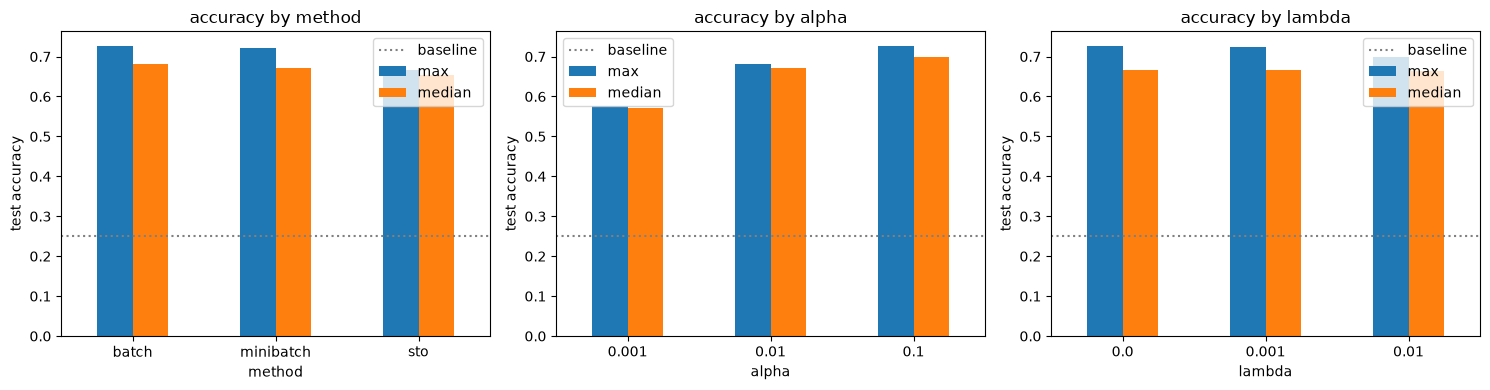

--- method ---
              max  median
method                   
batch      0.7269  0.6806
minibatch  0.7217  0.6718
sto        0.6674  0.6542 

--- alpha ---
          max  median
alpha                
0.001  0.5764  0.5720
0.010  0.6806  0.6718
0.100  0.7269  0.6997 

--- lambda ---
           max  median
lambda                
0.000   0.7269  0.6674
0.001   0.7232  0.6659
0.010   0.6997  0.6645 



In [58]:
# which factor matters most? best accuracy achieved by each level
res_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, factor in zip(axes, ['method', 'alpha', 'lambda']):
    grp = res_df.groupby(factor)['accuracy'].agg(['max', 'median'])
    grp.plot(kind='bar', ax=ax, rot=0)
    ax.axhline(0.25, color='grey', linestyle=':', label='baseline')
    ax.set_title(f'accuracy by {factor}'); ax.set_ylabel('test accuracy'); ax.legend()
plt.tight_layout(); plt.show()

for factor in ['method', 'alpha', 'lambda']:
    print(f"--- {factor} ---")
    print(res_df.groupby(factor)['accuracy'].agg(['max', 'median']).round(4).to_string(), "\n")

### 18. Saving the best model

In [59]:
INPUT_COLUMNS = ['brand', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
                 'owner', 'mileage', 'engine', 'max_power', 'seats']

class CarPriceClassifier(mlflow.pyfunc.PythonModel):
    """Preprocessor + from-scratch logistic regression in one object.

    predict() takes a DataFrame of raw car details and returns the price class (0-3).
    Missing columns/values are allowed: they become NaN and are imputed by the
    preprocessor exactly as during training.
    """

    def __init__(self, preprocessor, model, price_bins):
        self.preprocessor = preprocessor
        self.model = model
        self.price_bins = [float(b) for b in price_bins]   # so the app can show the band

    def _prepare(self, model_input):
        if not isinstance(model_input, pd.DataFrame):
            model_input = pd.DataFrame(model_input)
        model_input = model_input.copy()
        for c in INPUT_COLUMNS:                    # tolerate a form that omits a field entirely
            if c not in model_input.columns:
                model_input[c] = np.nan
        Xp = self.preprocessor.transform(model_input[INPUT_COLUMNS])
        return np.concatenate([np.ones((Xp.shape[0], 1)), Xp], axis=1)   # intercept column

    def predict(self, context, model_input, params=None):
        return self.model.predict(self._prepare(model_input))

    def predict_proba(self, model_input):
        return self.model.predict_proba(self._prepare(model_input))

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
CATEGORICAL_COLUMNS = ['brand', 'fuel', 'seller_type', 'transmission']
NUMERIC_COLUMNS = [c for c in INPUT_COLUMNS if c not in CATEGORICAL_COLUMNS]

# every column optional, numbers as double so they can be NaN
signature = ModelSignature(
    inputs=Schema([ColSpec('string' if c in CATEGORICAL_COLUMNS else 'double', c, required=False)
                   for c in INPUT_COLUMNS]),
    outputs=Schemsa([ColSpec('long')]),      # the predicted class, 0-3
)

def build_input_row(**values):
    """Build a one-row DataFrame the way the web app will: None for a blank dropdown,
    NaN for a blank number, and dtypes that match the signature above."""
    frame = pd.DataFrame([{c: values.get(c, None) for c in INPUT_COLUMNS}])
    for c in CATEGORICAL_COLUMNS:
        frame[c] = frame[c].astype(object)                  # stays object even when None
    for c in NUMERIC_COLUMNS:
        frame[c] = pd.to_numeric(frame[c], errors='coerce').astype('float64')
    return frame

print(signature)

inputs: 
  ['brand': string (optional), 'year': double (optional), 'km_driven': double (optional), 'fuel': string (optional), 'seller_type': string (optional), 'transmission': string (optional), 'owner': double (optional), 'mileage': double (optional), 'engine': double (optional), 'max_power': double (optional), 'seats': double (optional)]
outputs: 
  [long (required)]
params: 
  None



In [61]:
# retrain the winning configuration
best = table.iloc[0]
best_cfg = {'method': best['method'], 'alpha': float(best['alpha']), 'lambda': float(best['lambda'])}
print("best configuration:", best_cfg, f"(test accuracy {best['accuracy']:.4f})")

best_penalty = NoPenalty() if best_cfg['lambda'] == 0.0 else RidgePenalty(best_cfg['lambda'])
best_model = LogisticRegression(k=k, n=n, method=best_cfg['method'], alpha=best_cfg['alpha'],
                                max_iter=MAX_ITER, regularization=best_penalty, init='zeros',
                                verbose=False, seed=RANDOM_STATE)
best_model.fit(X_train_np, Y_train_encoded)

wrapped_model = CarPriceClassifier(preprocessor, best_model, price_bins)

# sanity check: does it work straight from raw rows?
example_input = X_test.head(3).astype({c: 'float64' for c in
                                       ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']})
print("\nraw input:"); display(example_input)
print("predicted classes:", wrapped_model.predict(None, example_input))
print("actual classes   :", y_test_np[:3])

best configuration: {'method': 'batch', 'alpha': 0.1, 'lambda': 0.0} (test accuracy 0.7269)

raw input:


,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
6040,Chevrolet,2015.0,197000.0,Diesel,Individual,Manual,1.0,13.58,2499.0,72.4,10.0
1378,Maruti,2010.0,120000.0,Diesel,Individual,Manual,4.0,19.30,1248.0,73.9,5.0
2718,Maruti,2014.0,84000.0,Diesel,Individual,Manual,1.0,23.40,1248.0,74.0,5.0


predicted classes: [2 0 1]
actual classes   : [2 1 2]


---
## Part D - Task 3, Objective 2: Register the model and move it to Staging

The best model is be registered in the MLflow **Models** module under the name
`st126956-a3-model`, and to be at the **Staging** stage.

The best model is logged as an **`mlflow.pyfunc` model that carries its own preprocessor**, so `predict()` takes
a raw DataFrame of car details and returns the price class. `code_paths=["logistic_regression.py"]` packages the
model classes with it, which is what lets the CI container load it without any training code.

In [62]:
with mlflow.start_run(run_name=f"FINAL-{best_cfg['method']}-a{best_cfg['alpha']}-l{best_cfg['lambda']}") as run:
    mlflow.log_params({**best_cfg, 'max_iter': MAX_ITER, 'stage': 'final'})
    mlflow.log_metrics({m: float(best[m]) for m in
                        ['accuracy', 'macro_f1', 'weighted_f1', 'train_accuracy']})

    # registered_model_name -> creates/updates st126956-a3-model in the Models module
    log_kwargs = dict(python_model=wrapped_model,
                      code_paths=['logistic_regression.py'],
                      signature=signature,            # declared by hand, see above
                      input_example=example_input,
                      registered_model_name=MODEL_NAME)
    try:
        model_info = mlflow.pyfunc.log_model(name='model', **log_kwargs)     # mlflow >= 3
    except TypeError:
        model_info = mlflow.pyfunc.log_model(artifact_path='model', **log_kwargs)  # mlflow 2.x

    final_run_id = run.info.run_id

print("logged model uri:", model_info.model_uri)
print("registered as   :", MODEL_NAME)

2026/09/28 19:23:57 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/09/28 19:23:57 INFO mlflow.pyfunc: Validating input example against model signature


logged model uri: models:/m-3b807db4d37e454599ced2faff75f715
registered as   : st126956-a3-model


Successfully registered model 'st126956-a3-model'.
Created version '1' of model 'st126956-a3-model'.


In [63]:
# move the newest version to Staging
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
latest = max(versions, key=lambda v: int(v.version))
print(f"{MODEL_NAME} version {latest.version}")

try:
    # MLflow 2.x and 3.x still support named stages
    client.transition_model_version_stage(name=MODEL_NAME, version=latest.version,
                                          stage='Staging', archive_existing_versions=False)
    print("-> stage set to Staging")
except Exception as exc:
    # very new MLflow builds drop stages in favour of aliases; fall back to one
    print(f"stages unavailable ({type(exc).__name__}), setting the 'staging' alias instead")
    client.set_registered_model_alias(MODEL_NAME, 'staging', latest.version)
    print("-> alias @staging set")

st126956-a3-model version 1
-> stage set to Staging


C:\Users\User\AppData\Local\Temp\ipykernel_25028\1609939252.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(name=MODEL_NAME, version=latest.version,


In [64]:
# load it back exactly the way the web app and the CI tests will
staging_model = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}/Staging")
preds = staging_model.predict(example_input)
print("loaded from the registry at Staging")
print("predictions:", preds)
assert len(preds) == len(example_input), "one prediction per input row"

# the cases the web app has to survive
print("\nevery field blank       :", staging_model.predict(build_input_row()))
print("only brand and year     :", staging_model.predict(build_input_row(brand='Maruti', year=2018.0)))
print("a cheap old hatchback   :", staging_model.predict(build_input_row(
    brand='Maruti', year=2010.0, km_driven=120000.0, fuel='Petrol', seller_type='Individual',
    transmission='Manual', owner=3.0, mileage=19.0, engine=796.0, max_power=47.0, seats=5.0)))
print("a recent premium car    :", staging_model.predict(build_input_row(
    brand='BMW', year=2020.0, km_driven=15000.0, fuel='Diesel', seller_type='Dealer',
    transmission='Automatic', owner=1.0, mileage=15.0, engine=2998.0, max_power=250.0, seats=5.0)))
print("\nround trip OK")

loaded from the registry at Staging
predictions: [2 0 1]

every field blank       : [1]
only brand and year     : [3]
a cheap old hatchback   : [0]
a recent premium car    : [3]

round trip OK


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


**Adding screenshots for locally logged mlflow experiment** 
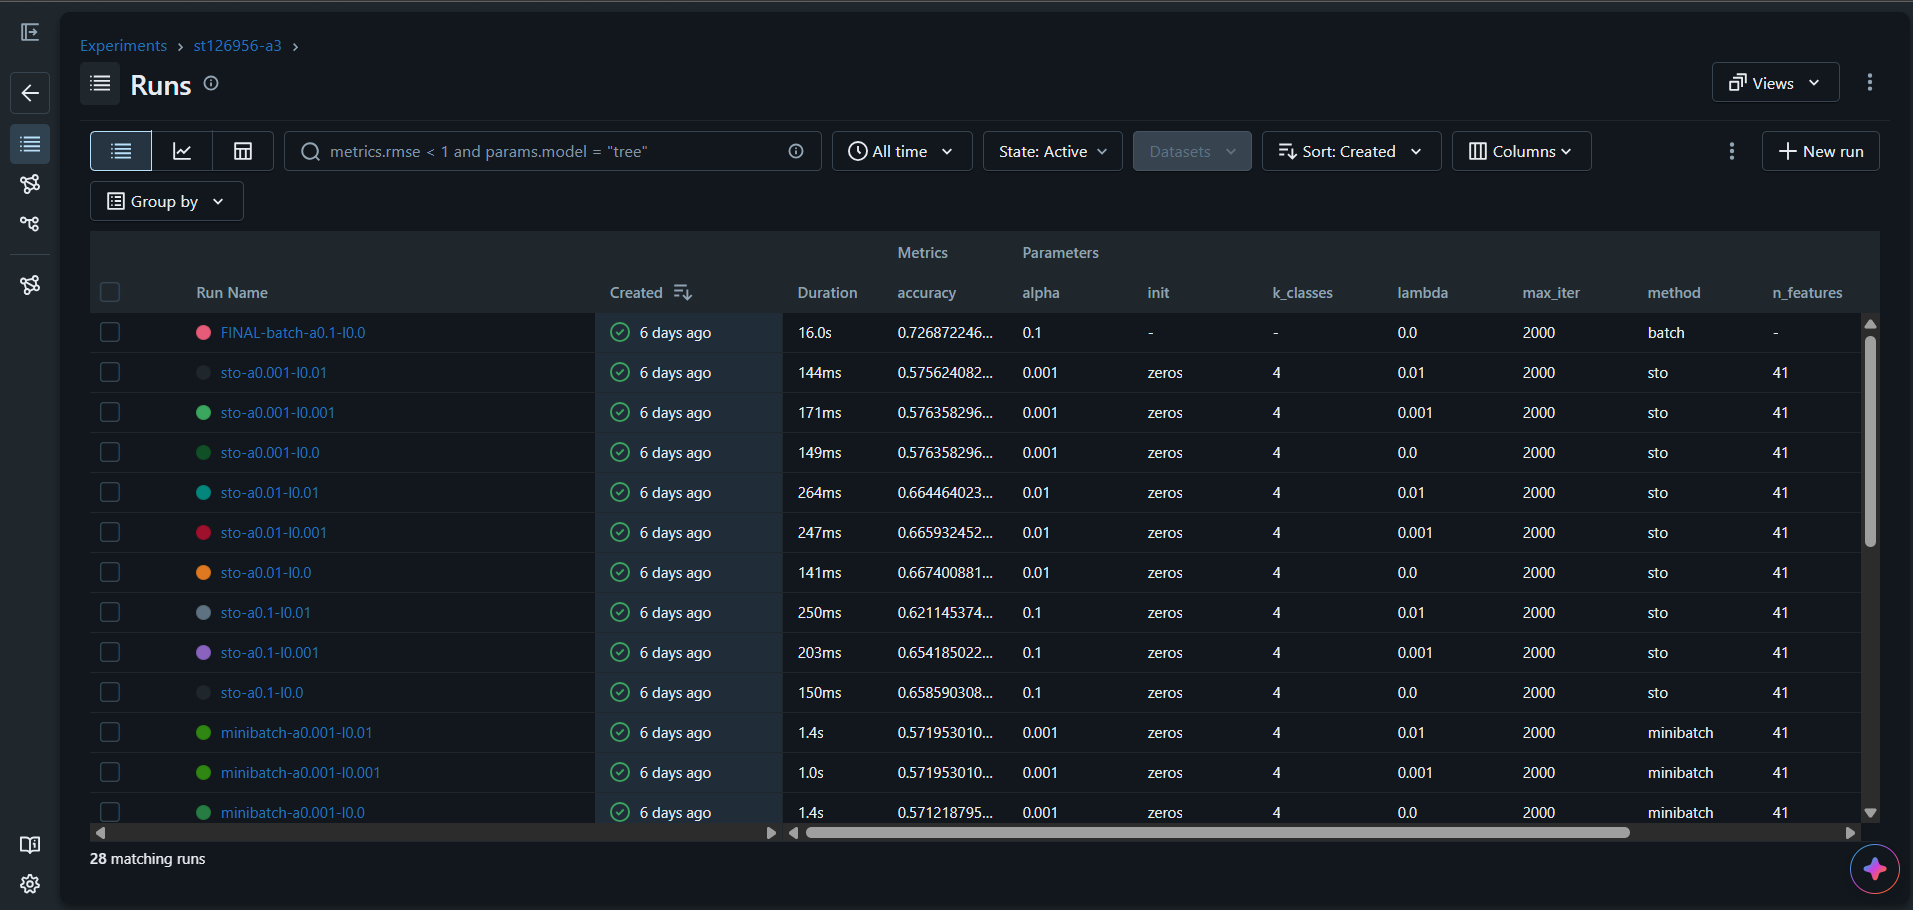


MLFlow model staging
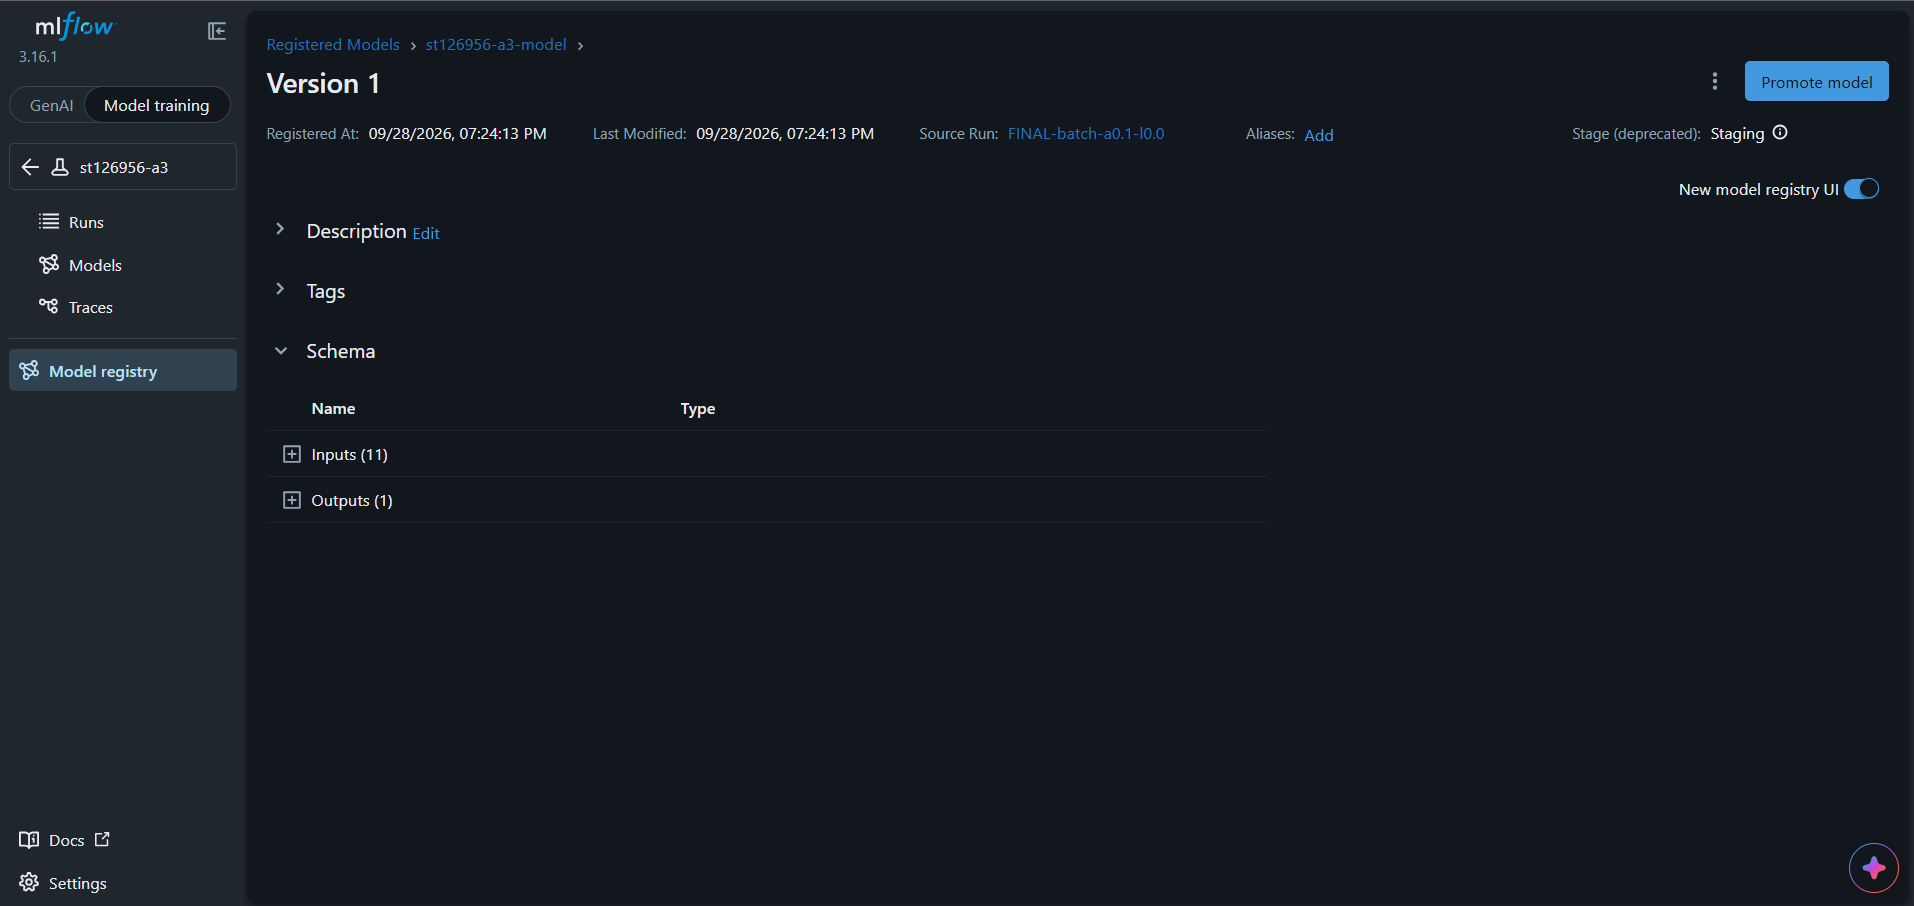

### Why the model is logged this way

The registry stores one object that already knows how to preprocess, so anything that loads
`models:/st126956-a3-model/Staging` can predict from raw car details without importing the notebook. That is what
makes the CI/CD step in Objective 3 possible: the container can pull the model straight from the registry and check
it, with no training code involved.

---
## Part D - Task 3, Objective 3: CI/CD

`.github/workflows/build-test.yml` runs on every push:

1. build the image and start the container;
2. run `pytest test_model.py` **inside** the container;
3. only on `main`, and only if the tests passed, log in to Docker Hub and push the image;
4. then SSH to ml-brain through the bazooka jump host and `docker compose pull && up -d`.

The deploy job declares `needs: build-test`, which is what makes the deployment conditional: if a test fails,
GitHub never starts the deploy job, so a broken commit cannot reach the server.

![GitHub Actions run green: build-test and deploy both passed](Screenshots/actions_green.png)


*A push to `main` running the full pipeline — build-test then deploy, both green.*

![Deploy job output: SSH succeeded and the container is Up](Screenshots/deploy_job.png)

*The deploy job: SSH through bazooka succeeds and `docker compose ps` shows `web-st126956` running the pushed image.*

**The two required unit tests** are in `app/code/test_model.py`:

* `test_model_takes_expected_input` — the model accepts the 11-column DataFrame the Dash callback builds, with
  the dtypes the signature requires.
* `test_model_output_shape` — one input row gives exactly one prediction, *n* rows give *n*, and the values are
  class labels in 0–3.

Five extra tests cover the blank-field cases, an unknown brand, and a sanity check that a recent premium car is
not ranked below an old budget one.

**Model loading.** `utils.load_model()` tries the MLflow registry first and falls back to the copy inside the
image. That keeps both the site and CI working when the MLflow server is down, and means the deployed site does
not go offline if the server disappears later.

**Note on public HTTPS.** The pipeline deploys successfully and the container serves the app (HTTP 200 on the
`web` network, confirmed from the host). Public access over HTTPS was intermittently blocked by a server-side
Traefik/ACME issue on ml-brain that affected several students during this window; the pipeline, image, and
container are unaffected.

## Screenshots

All evidence is in the `Screenshots/` folder and embedded above:

| File | Shows |
|---|---|
| `mlflow_experiment.png` | the `st126956-a3` experiment with the 27 runs (Objective 1) |
| `mlflow_model_staging.png` | `st126956-a3-model` at the Staging stage (Objective 2) |
| `actions_green.png` | the GitHub Actions pipeline passing end-to-end (Objective 3) |
| `deploy_job.png` | the deploy job: SSH + `docker compose ps` with the container Up (Objective 3) |

## Running it

```bash
# notebook
pip install -r app/code/requirements.txt
jupyter lab A3_car_price_classification.ipynb

# view the logged MLflow runs locally
mlflow ui --backend-store-uri sqlite:///mlflow.db   # http://127.0.0.1:5000

# the app, locally
cd app/code && python main.py           # http://127.0.0.1:8050

# the app, in Docker (from the repo root)
docker compose -f app/docker-compose.yaml up --build

# the tests
cd app/code && pytest test_model.py -v
```

## GitHub settings the workflow needs

| Kind | Name | Value |
|---|---|---|
| Secret | `DOCKERHUB_USERNAME` | `psyduckait` |
| Secret | `DOCKERHUB_TOKEN` | an access token from Docker Hub → Account Settings → Personal access tokens |
| Secret | `USERNAME` | `st126956` |
| Secret | `KEY` | the **private** SSH key that matches the public key submitted to the course |
| Secret | `APP_MODEL_NAME` | `st126956-a3-model` |
| Secret | `MLFLOW_TRACKING_URI` | optional — leave unset to serve the model bundled in the image |
| Variable | `HOST` | `ml.brain.cs.ait.ac.th` |
| Variable | `PROXY_HOST` | `bazooka.cs.ait.ac.th` |
